In [95]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from snsphd.viz import phd_style

from util.pcr_loader import PcrLoader

colors, swatches = phd_style(jupyterStyle=True)

SHOW_DARK = True
X_LIMITS = None
Y_LIMITS = None

DATASETS = {
    "35 um": {
        "path": "../data/DC_Pa250528a_60nm_hero/35um/6_1snap_w0.06_l50_35micron_1.9thermal_start_265_end_XXX.csv",
        "threshold": 0.010,
    },
    "42 um": {
        "path": "../data/DC_Pa250528a_60nm_hero/42um/6_1snap_w0.06_l50_42um_2.2thermal_start_261_end_XXX.csv",
        "threshold": 0.012,
    },
    "46 um (QCL)": {
        # "path": "../data/DC_Pa250528a_60nm_hero/46um_QCL/2.11.2026/qcl_30Hz_280mA_30.0V__0.002_time_10s_x6cycles_start_258mK.csv",
        "path": "../data/DC_Pa250528a_60nm_hero/46um_QCL/3.25.2026/46um_40Hz_30.7V_262mA_267mK_positivepulse_start_100us_end_300us_total_QCL_350us_3.0sx10cycle.csv",
        "threshold": 0.014,
    },
    "63 um (QCL)": {
        "path": "../data/DC_Pa250528a_60nm_hero/63um_QCL/3.26.2026/63um_160Hz_6.34V_27.2mA_252mK_positivepulse_start_100us_end_300us_total_QCL_350us_3.0sx4cycle.csv",
        "threshold": 0.012,
    },
}

PLOT_COLORS = {
    "35 um": plt.cm.plasma(0.15),
    "42 um": plt.cm.plasma(0.40),
    "46 um (QCL)": plt.cm.plasma(0.65),
    "63 um (QCL)": plt.cm.plasma(0.90),
}
MARKERS = {
    "35 um": "o",
    "42 um": "^",
    "46 um (QCL)": "D",
    "63 um (QCL)": "s",
}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [96]:
# Load each CSV once so threshold maps are easy to inspect.
datasets = {label: PcrLoader.from_threshold_csv(spec["path"]) for label, spec in DATASETS.items()}

for label, dataset in datasets.items():
    print(label, dataset.threshold_map())


35 um {1: 0.007, 2: 0.008, 3: 0.01}
42 um {1: 0.008, 2: 0.01, 3: 0.012}
46 um (QCL) {1: 0.008, 2: 0.01, 3: 0.012, 4: 0.014}
63 um (QCL) {1: 0.008, 2: 0.01, 3: 0.012, 4: 0.014}


35 um: counts@0.09 uA = 24372.2, scale = 0.000041
42 um: counts@0.09 uA = 28586.7, scale = 0.000035
46 um (QCL): counts@0.09 uA = 41019.8, scale = 0.000024
63 um (QCL): counts@0.09 uA = 33332.7, scale = 0.000030


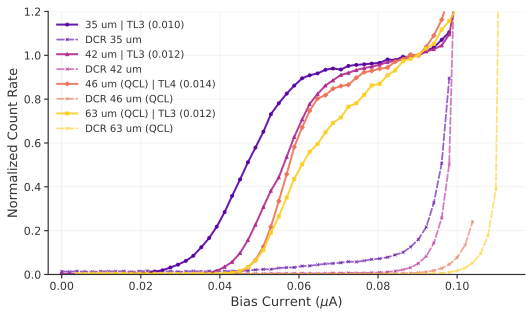

In [101]:
AUTO_SCALE = True  # True = normalize all curves to 1.0 at NORMALIZE_BIAS; False = use manual SCALE_FACTOR
NORMALIZE_BIAS = 0.09  # uA – only used when AUTO_SCALE is True

MANUAL_SCALE_FACTOR = {
    "35 um": 1.0,
    "42 um": 0.85,
    "46 um (QCL)": 0.59,
    "63 um (QCL)": 0.71,
}

OFFSET_X = {
    "35 um": 0,
    "42 um": 0,
    "46 um (QCL)": 0,
    "63 um (QCL)": 0,
}

OFFSET_Y = {
    "35 um": 0,
    "42 um": 0,
    "46 um (QCL)": 0,
    "63 um (QCL)": 0,
}

CROP_END = {
    "35 um": -5,
    "42 um": -4,
    "46 um (QCL)": -1,
    "63 um (QCL)": -1,
}

# These manual tweaks align the four device curves on one figure.
curves = {
    label: datasets[label].get_curve(spec["threshold"], label=label)
    for label, spec in DATASETS.items()
}

# Compute scale factors
if AUTO_SCALE:
    SCALE_FACTOR = {}
    for label, curve in curves.items():
        val_at_norm = np.interp(NORMALIZE_BIAS, curve.bias_uA, curve.counts)
        SCALE_FACTOR[label] = 1.0 / val_at_norm if val_at_norm != 0 else 1.0
        print(f"{label}: counts@{NORMALIZE_BIAS} uA = {val_at_norm:.1f}, scale = {SCALE_FACTOR[label]:.6f}")
else:
    SCALE_FACTOR = MANUAL_SCALE_FACTOR


fig, ax = plt.subplots(figsize=(7.5, 4.5))

for label, curve in curves.items():
    ax.plot(
        curve.bias_uA[:CROP_END[label]] + OFFSET_X[label],
        (curve.counts[:CROP_END[label]] + OFFSET_Y[label]) * SCALE_FACTOR[label],
        marker=MARKERS[label],
        color=PLOT_COLORS[label],
        linewidth=2.0,
        markersize=3,
        alpha=0.9,
        label=f"{label} | {curve.threshold.label}",
    )
    if SHOW_DARK and curve.dark_counts is not None:
        ax.plot(
            curve.bias_uA[: CROP_END[label]] + OFFSET_X[label],
            (curve.dark_counts[: CROP_END[label]] + OFFSET_Y[label]) * SCALE_FACTOR[label],
            marker="x",
            color=PLOT_COLORS[label],
            linewidth=1.8,
            markersize=3,
            alpha=0.6,
            linestyle="--",
            label=f"DCR {label}",
        )

# if AUTO_SCALE:
#     ax.axvline(NORMALIZE_BIAS, color="gray", linestyle=":", linewidth=1, alpha=0.5)
ax.set_xlabel(r"Bias Current ($\mu$A)")
ax.set_ylabel("Normalized Count Rate" if AUTO_SCALE else "Photon Count Rate (cps)")
if X_LIMITS is not None:
    ax.set_xlim(*X_LIMITS)
if Y_LIMITS is not None:
    ax.set_ylim(*Y_LIMITS)
ax.legend(frameon=False, loc="upper left", fontsize=10)
ax.grid(alpha=0.2)

if AUTO_SCALE:
    ax.set_ylim(0, 1.2)
else:

    ax.set_ylim(0, 40000)

plt.tight_layout()

out_dir = Path("../out/60nm_hero")
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / "hero_35_42_46_63um_counts.png", dpi=300)
fig.savefig(out_dir / "hero_35_42_46_63um_counts.pdf", dpi=300)
plt.show()